# Beyond the repair event

**B106 Data Visualisation - Individual Project**

### Which products should receive follow-up support?

**Who:** This data analysis is intended for the coordinator of a (fictional) community repair network. The coordinator wants to start a follow-up programme for products that were not fixed at a repair event, though recorded as Repairable.

**What:** The project aims to identify which product categories should be prioritised for a pilot programme and what kind of support could be prepared, including help finding spare parts, arranging another appointment or referring owners to specialists. The analysis should help the coordinator choose an initial focus and understand what preparation might be needed.

**How:** The analysis is based on the Open Repair Alliance dataset using records from 2024. Seven insights compare case volumes, Repairable shares, differences between providers, patterns over time, local group workloads, brands and product ages.

## Data and preparation

### Data source and scope

The full dataset is the Open Repair Alliance July 2025 aggregate snapshot, featuring data from June 2012 to July 2025 and has 305,649 records and 14 columns (Open Repair Alliance, 2025). Each record is one repair attempt on a product and one product can have multiple events/records. I focus on data from 2024, as this is the latest complete calendar year in the snapshot.

Example records from the full snapshot:

In [1]:
import pandas as pd

raw = pd.read_csv('data/OpenRepairData_v0.3_aggregate_202507.csv', low_memory=False)
print(f"Full snapshot: {len(raw):,} attempts and {raw.shape[1]} columns")
preview = raw.head()[['product_category', 'repair_status', 'product_age', 'event_date']].copy()
preview.columns = ['Product category', 'Outcome', 'Age (years)', 'Event date']
preview.style.format({'Age (years)': '{:g}'}, na_rep='Not recorded').hide(axis='index')

Full snapshot: 305,649 attempts and 14 columns


Product category,Outcome,Age (years),Event date
Headphones,End of life,Not recorded,2025-07-28
Laptop,End of life,Not recorded,2025-07-28
Iron,Repairable,Not recorded,2025-07-28
Food processor,Fixed,Not recorded,2025-07-28
Laptop,Fixed,Not recorded,2025-07-28


### Data quality and preparation

In the next step the data is prepared for further analysis by parsing dates, selecting just 2024 records, deriving the event month from the date and cleaning the brand names by standardising case and surrounding whitespaces, as well as grouping unknown labels. In 2024 65.8% of records didn't include a product age, which is kept as NaN and not filled with zeros. The 2024 sample contains seven providers and 21 country codes with uneven representation.

In [2]:
data = raw.copy()
data['event_date'] = pd.to_datetime(data['event_date'])
year = data[data['event_date'].dt.year.eq(2024)].copy()
year['month'] = year['event_date'].dt.month
year['brand_clean'] = year['brand'].fillna('').str.strip().str.casefold()
year.loc[year['brand_clean'].isin(['', 'unknown']), 'brand_clean'] = 'Unknown'
print(f"Missing product age in full snapshot: {raw['product_age'].isna().mean():.1%}")
print(f"Missing product age in 2024: {year['product_age'].isna().mean():.1%}")

Missing product age in full snapshot: 66.6%
Missing product age in 2024: 65.8%


### Outcomes and Repairable share

| Outcome | Meaning |
|---|---|
| Fixed | Repaired at the event. |
| Repairable | Unfinished, with a further step identified. |
| End of life | Repair judged impractical. |
| Unknown | Outcome not established. |

In [3]:
year['is_repairable'] = year['repair_status'].eq('Repairable')
repairable = year[year['is_repairable']]
overall = 100 * len(repairable) / len(year)
print(f"2024 total attempts: {len(year):,}")
print(f"2024 Repairable attempts: {len(repairable):,}")
print(f"2024 Repairable share: {overall:.1f}%")

2024 total attempts: 85,515
2024 Repairable attempts: 14,702
2024 Repairable share: 17.2%


Out of the 85,515 total attempts (including "Unknown") in 2024, 14,702 were classified "Repairable" (Open Repair Alliance, n.d., The Restart Project, n.d.) meaning they are potential follow-up cases, while not being expected future successful repairs.

### Provider recording differences

In [4]:
statuses = ['Fixed', 'Repairable', 'End of life', 'Unknown']
provider_counts = pd.crosstab(year['data_provider'], year['repair_status'])[statuses]
provider_totals = provider_counts.sum(axis=1)
provider_summary = pd.DataFrame({'Total attempts': provider_totals,
    'Repairable (%)': 100 * provider_counts['Repairable'] / provider_totals,
    'Unknown (%)': 100 * provider_counts['Unknown'] / provider_totals})
provider_summary = provider_summary.sort_values('Total attempts', ascending=False).rename_axis('Provider')
provider_summary.style.format({'Total attempts': '{:,}', 'Repairable (%)': '{:.1f}', 'Unknown (%)': '{:.1f}'})

,Total attempts,Repairable (%),Unknown (%)
Provider,,,
The Restart Project,"31,262",25.0,0.7
Repair Café International,"27,757",15.2,0.0
Repair Café Denmark,"10,991",0.0,3.4
anstiftung,"8,863",16.0,2.2
Repair Cafe Wales,"5,957",19.6,8.2
Repair Café Toronto,548,6.6,58.8
Fixit Clinic,137,29.2,25.5


The different providers show varying totals and outcome mixes and recording and mapping practices may differ which has to be considered when interpreting combined results. Especially interesting is that Denmark reports no Repairable outcomes in 10,991 total attempts or the international Repair Café having zero Unknown outcomes.

### Plotting setup

I use consistent fonts, colours and heading layouts across all seven figures. This cell sets the shared theme and defines a function for chart titles, subtitles and source notes.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

NAVY, BLUE, GREY, INK = '#234E70', '#4D82AA', '#A8B1B9', '#263645'
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 300, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.labelcolor': INK,
                     'text.color': INK, 'xtick.color': INK, 'ytick.color': INK})
def heading(fig, title, subtitle):
    fig.text(.01, .99, title, fontsize=18, weight='bold', va='top')
    fig.text(.01, .92 - .065 * title.count('\n'), subtitle, fontsize=10, va='top')
    fig.text(.03, .015, 'Source: Open Repair Alliance, July 2025 snapshot.', fontsize=9)

## 1. A low fixed share can mislead follow-up selection

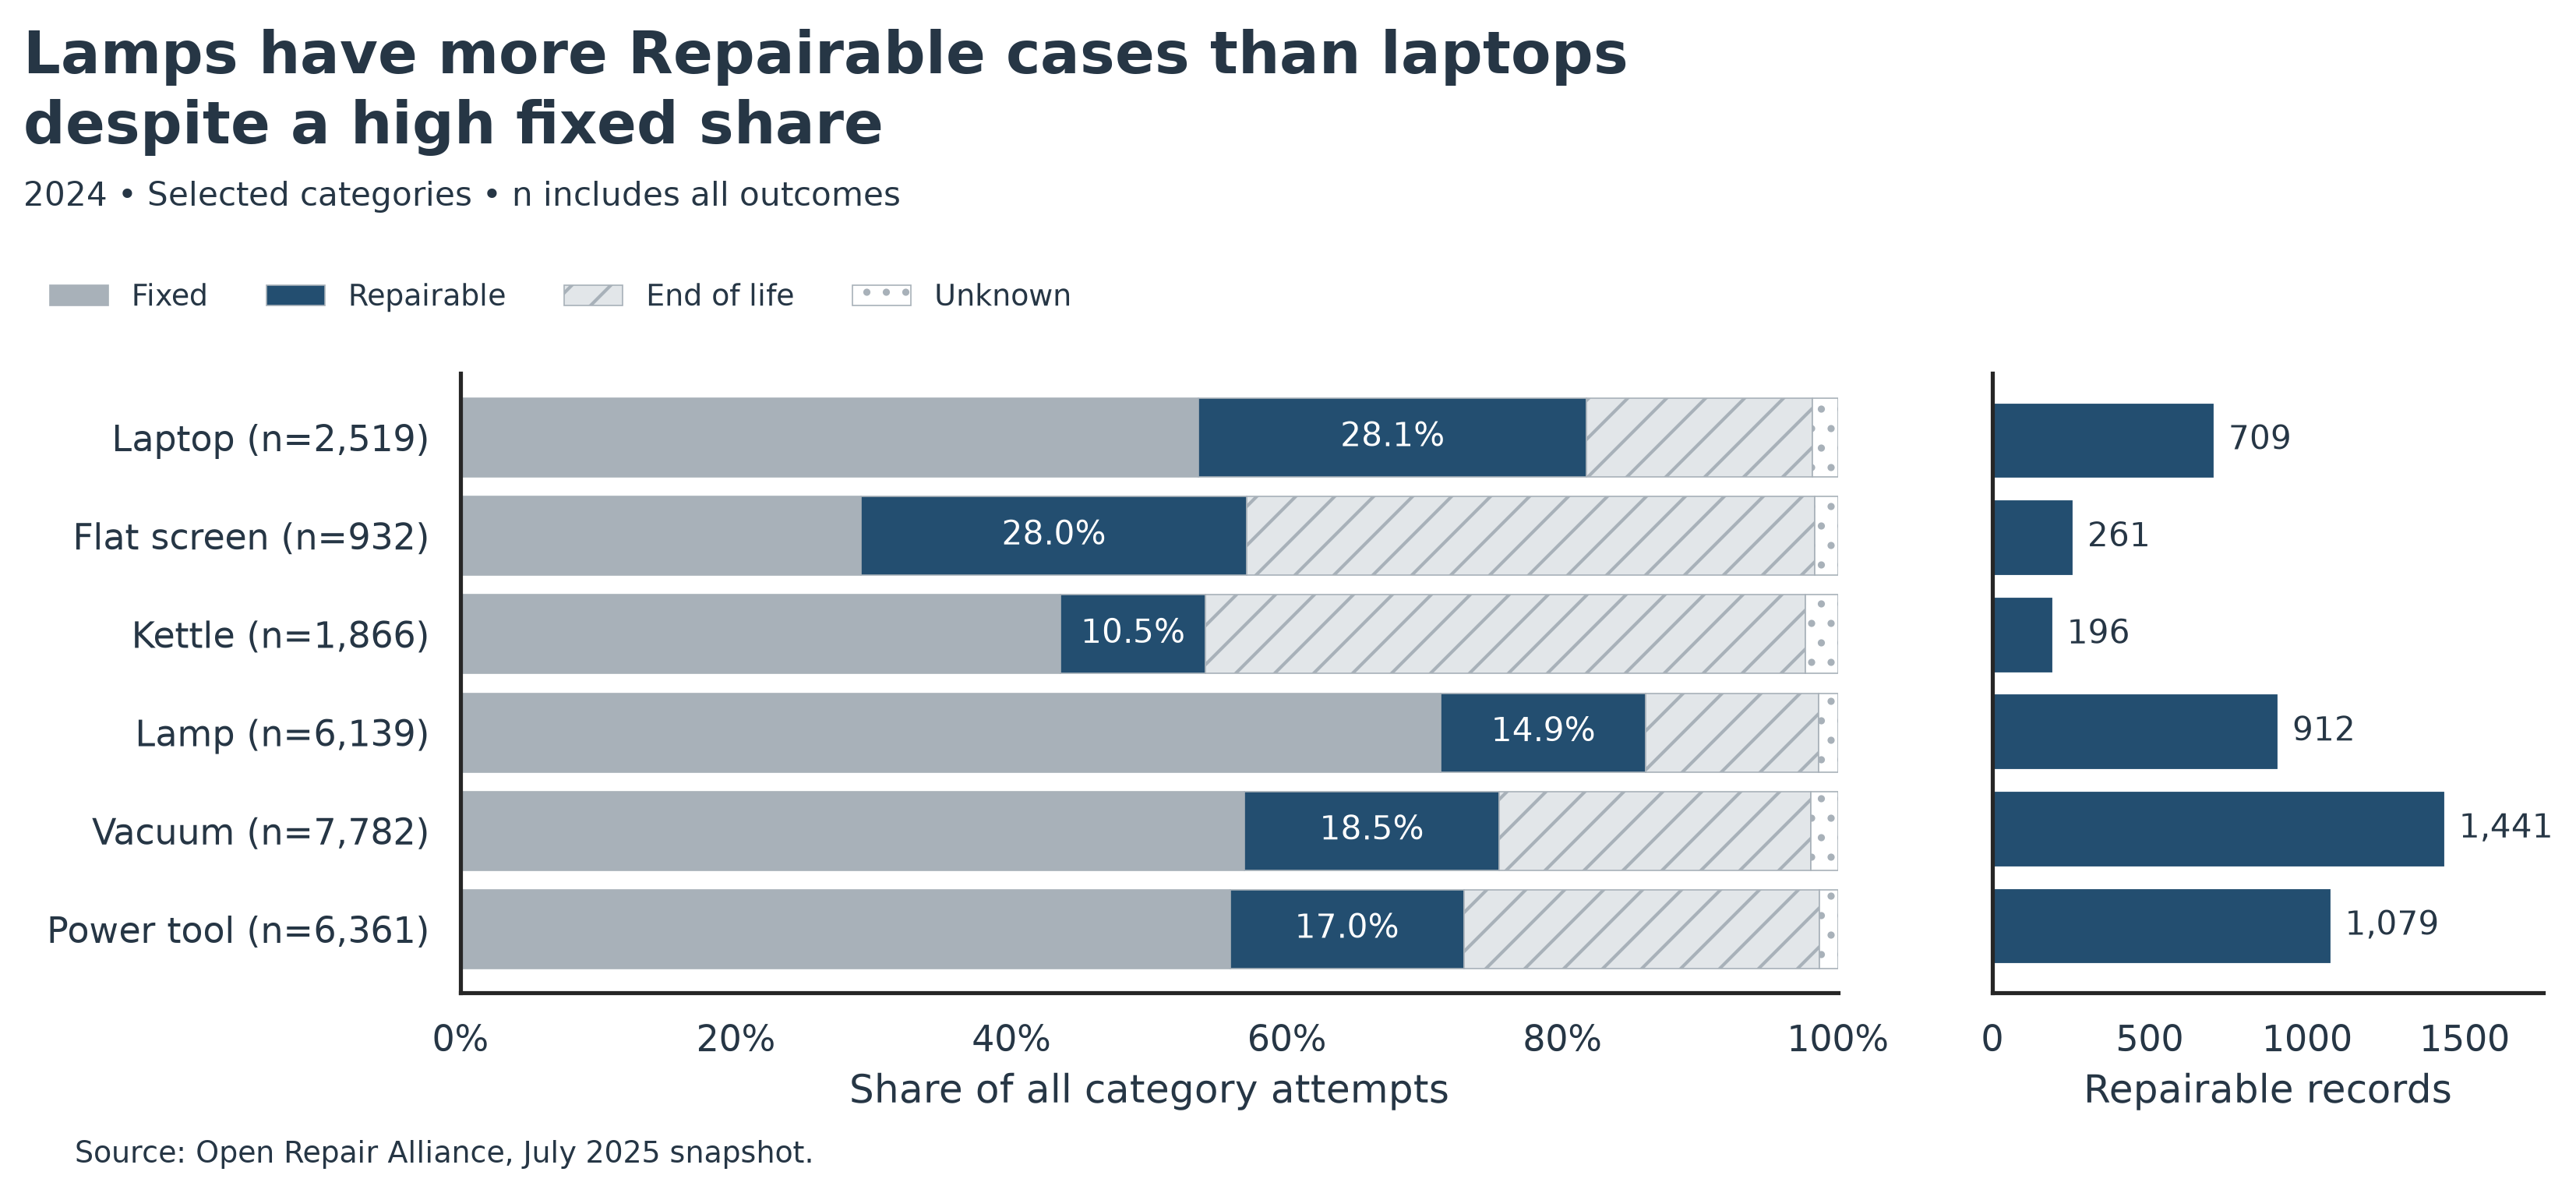

In [6]:
counts = pd.crosstab(year['product_category'], year['repair_status'])[statuses]
totals = counts.sum(axis=1)
shares = counts.div(totals, axis=0).mul(100)

selected = ['Laptop', 'Flat screen', 'Kettle', 'Lamp', 'Vacuum', 'Power tool']
fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [3, 1.2]})
shares.loc[selected].plot.barh(stacked=True, ax=axes[0], width=.8,
    color=[GREY, NAVY, '#E2E6E9', 'white'], edgecolor=GREY, linewidth=.4)
for container, hatch in zip(axes[0].containers, ['', '', '//', '..']):
    for bar in container:
        bar.set_hatch(hatch)
axes[0].bar_label(axes[0].containers[1], fmt='%.1f%%', label_type='center', color='white', fontsize=10)
axes[0].set_yticklabels([f'{c} (n={totals[c]:,})' for c in selected])
axes[0].set(xlim=(0, 100), xlabel='Share of all category attempts', ylabel='')
axes[0].xaxis.set_major_formatter(PercentFormatter(decimals=0))
fig.legend(*axes[0].get_legend_handles_labels(), ncol=4,
           bbox_to_anchor=(.01, .79), loc='upper left', frameon=False, fontsize=9)
axes[0].get_legend().remove()
axes[1].barh(selected, counts.loc[selected, 'Repairable'], color=NAVY)
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding=4, fontsize=10)
axes[1].set(xlim=(0, 1750), xlabel='Repairable records', yticks=[])
for ax in axes:
    ax.invert_yaxis()
heading(fig, 'Lamps have more Repairable cases than laptops\ndespite a high fixed share',
        '2024 • Selected categories • n includes all outcomes')
fig.subplots_adjust(left=.18, right=.99, top=.69, bottom=.16, wspace=.16)
plt.show()

The coordinator needs to distinguish potential follow-up cases from products judged impractical to repair. A low fixed share cannot identify that group, so Repairable shares and total counts should be considered.\
The stacked bars compare outcome composition, calculated by dividing outcomes per category by category totals, while the aligned count bars show the size of the Repairable pool. The dark blue directs attention to that outcome.

It can be observed that lamps have 912 Repairable cases compared to 709 cases of laptops, despite a Repairable share that is just around half the size laptops and a fixed share of 71.2% for lamps.

## 2. Volume and frequency produce different shortlists

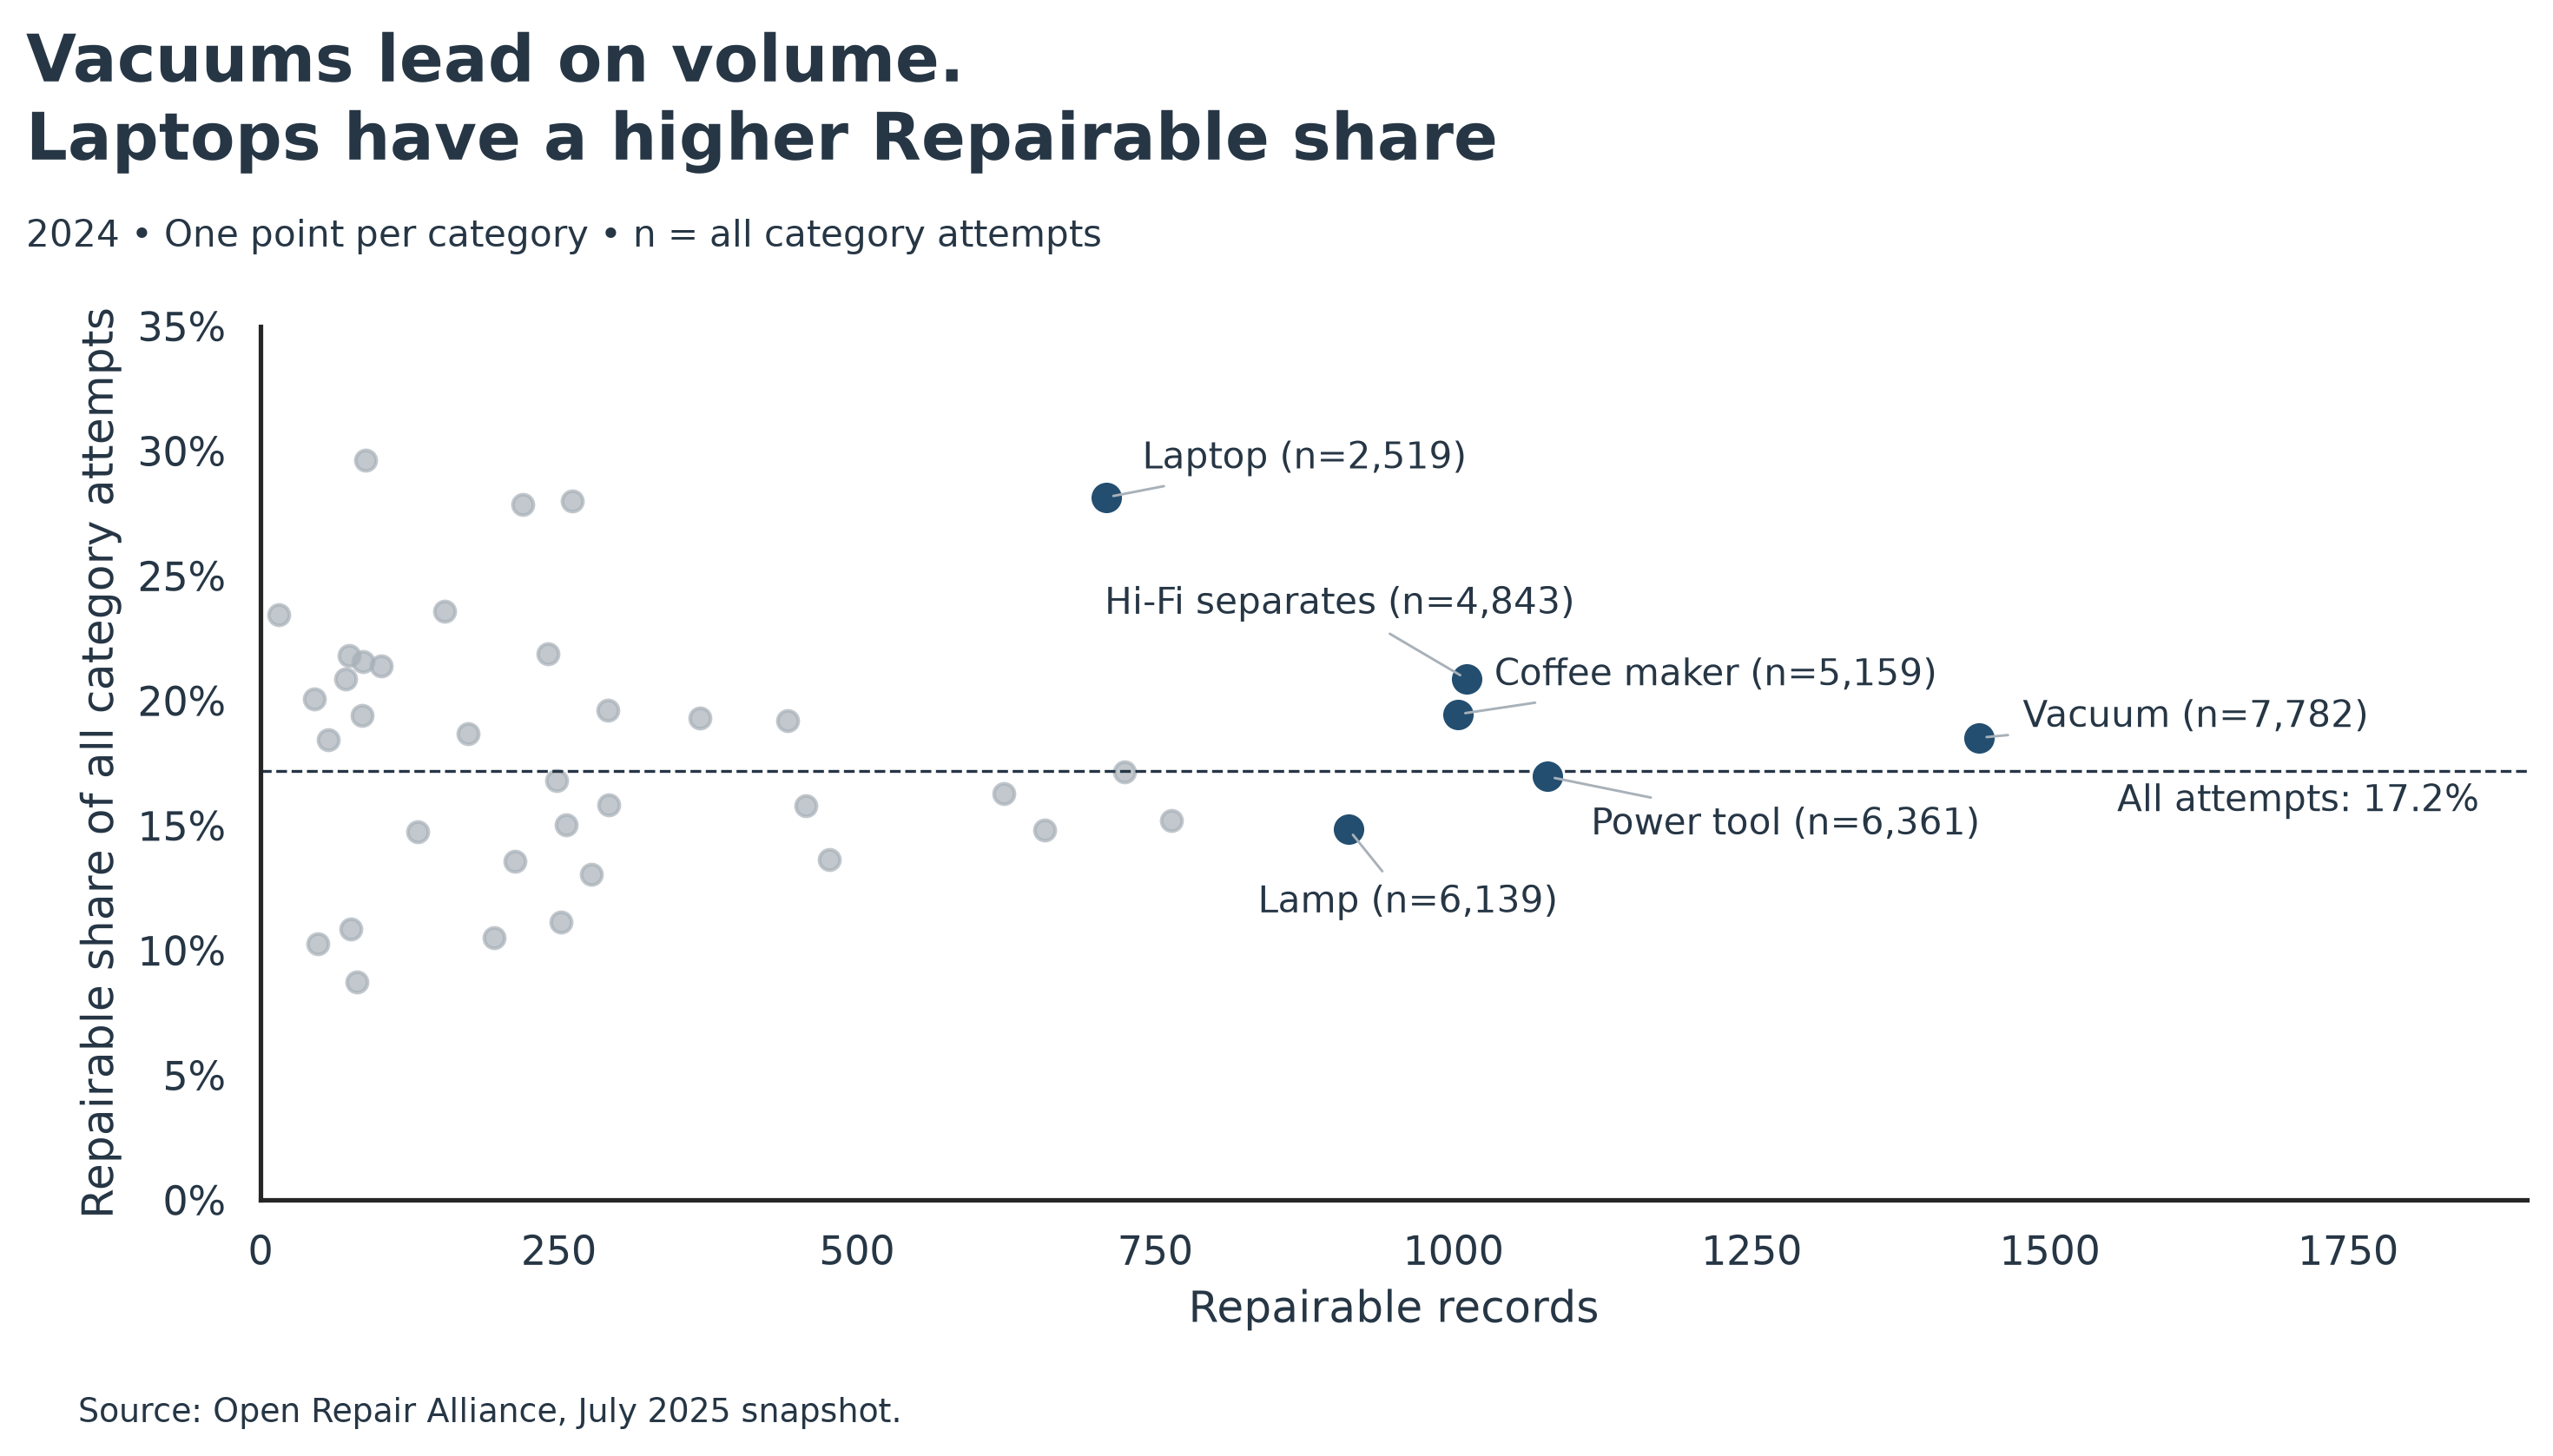

In [7]:
categories = ['Vacuum', 'Power tool', 'Hi-Fi separates', 'Coffee maker', 'Lamp', 'Laptop']

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(counts['Repairable'], shares['Repairable'], color=GREY, s=32, alpha=.7)
ax.scatter(counts.loc[categories, 'Repairable'], shares.loc[categories, 'Repairable'],
           color=NAVY, s=55, zorder=3)
offsets = [(12, 3), (12, -16), (-100, 18), (10, 8), (-25, -23), (10, 8)]
for category, offset in zip(categories, offsets):
    ax.annotate(f'{category} (n={totals[category]:,})',
                (counts.loc[category, 'Repairable'], shares.loc[category, 'Repairable']),
                xytext=offset, textcoords='offset points', fontsize=10,
                arrowprops={'arrowstyle': '-', 'color': GREY, 'lw': .7})
ax.axhline(overall, color=INK, lw=.8, ls='--')
ax.text(1860, overall - .5, f'All attempts: {overall:.1f}%', ha='right', va='top', fontsize=10)
ax.set(xlim=(0, 1900), ylim=(0, 35), xlabel='Repairable records',
       ylabel='Repairable share of all category attempts')
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
heading(fig, 'Vacuums lead on volume.\nLaptops have a higher Repairable share',
        '2024 • One point per category • n = all category attempts')
fig.subplots_adjust(left=.10, right=.97, top=.78, bottom=.17)
plt.show()

A category can have many follow-up cases because many products were brought in, even if its Repairable share is modest. The coordinator needs both measures to judge potential reach.

The scatterplot reuses the category counts from insight 1 but puts share and total in the same view. The most interesting points are highlighted and put into context by the overall Repairable share of 17.2%.\
While vacuums lead with 1,441 Repairable cases at a 18.5% share, Laptops are more often classified Repairable with a share of 28.1%, while having fewer total Repairable records. The total volume can be used to infer reach and share to assess frequency, but neither measure shows repair difficulty or later success.

## 3. The shortlist is more dependable than its ranking

The next insight shows the effects of different providers on the shortlist of categories and calculates count ranks excluding the largest providers (left) and the Repairable shares within single providers (right).

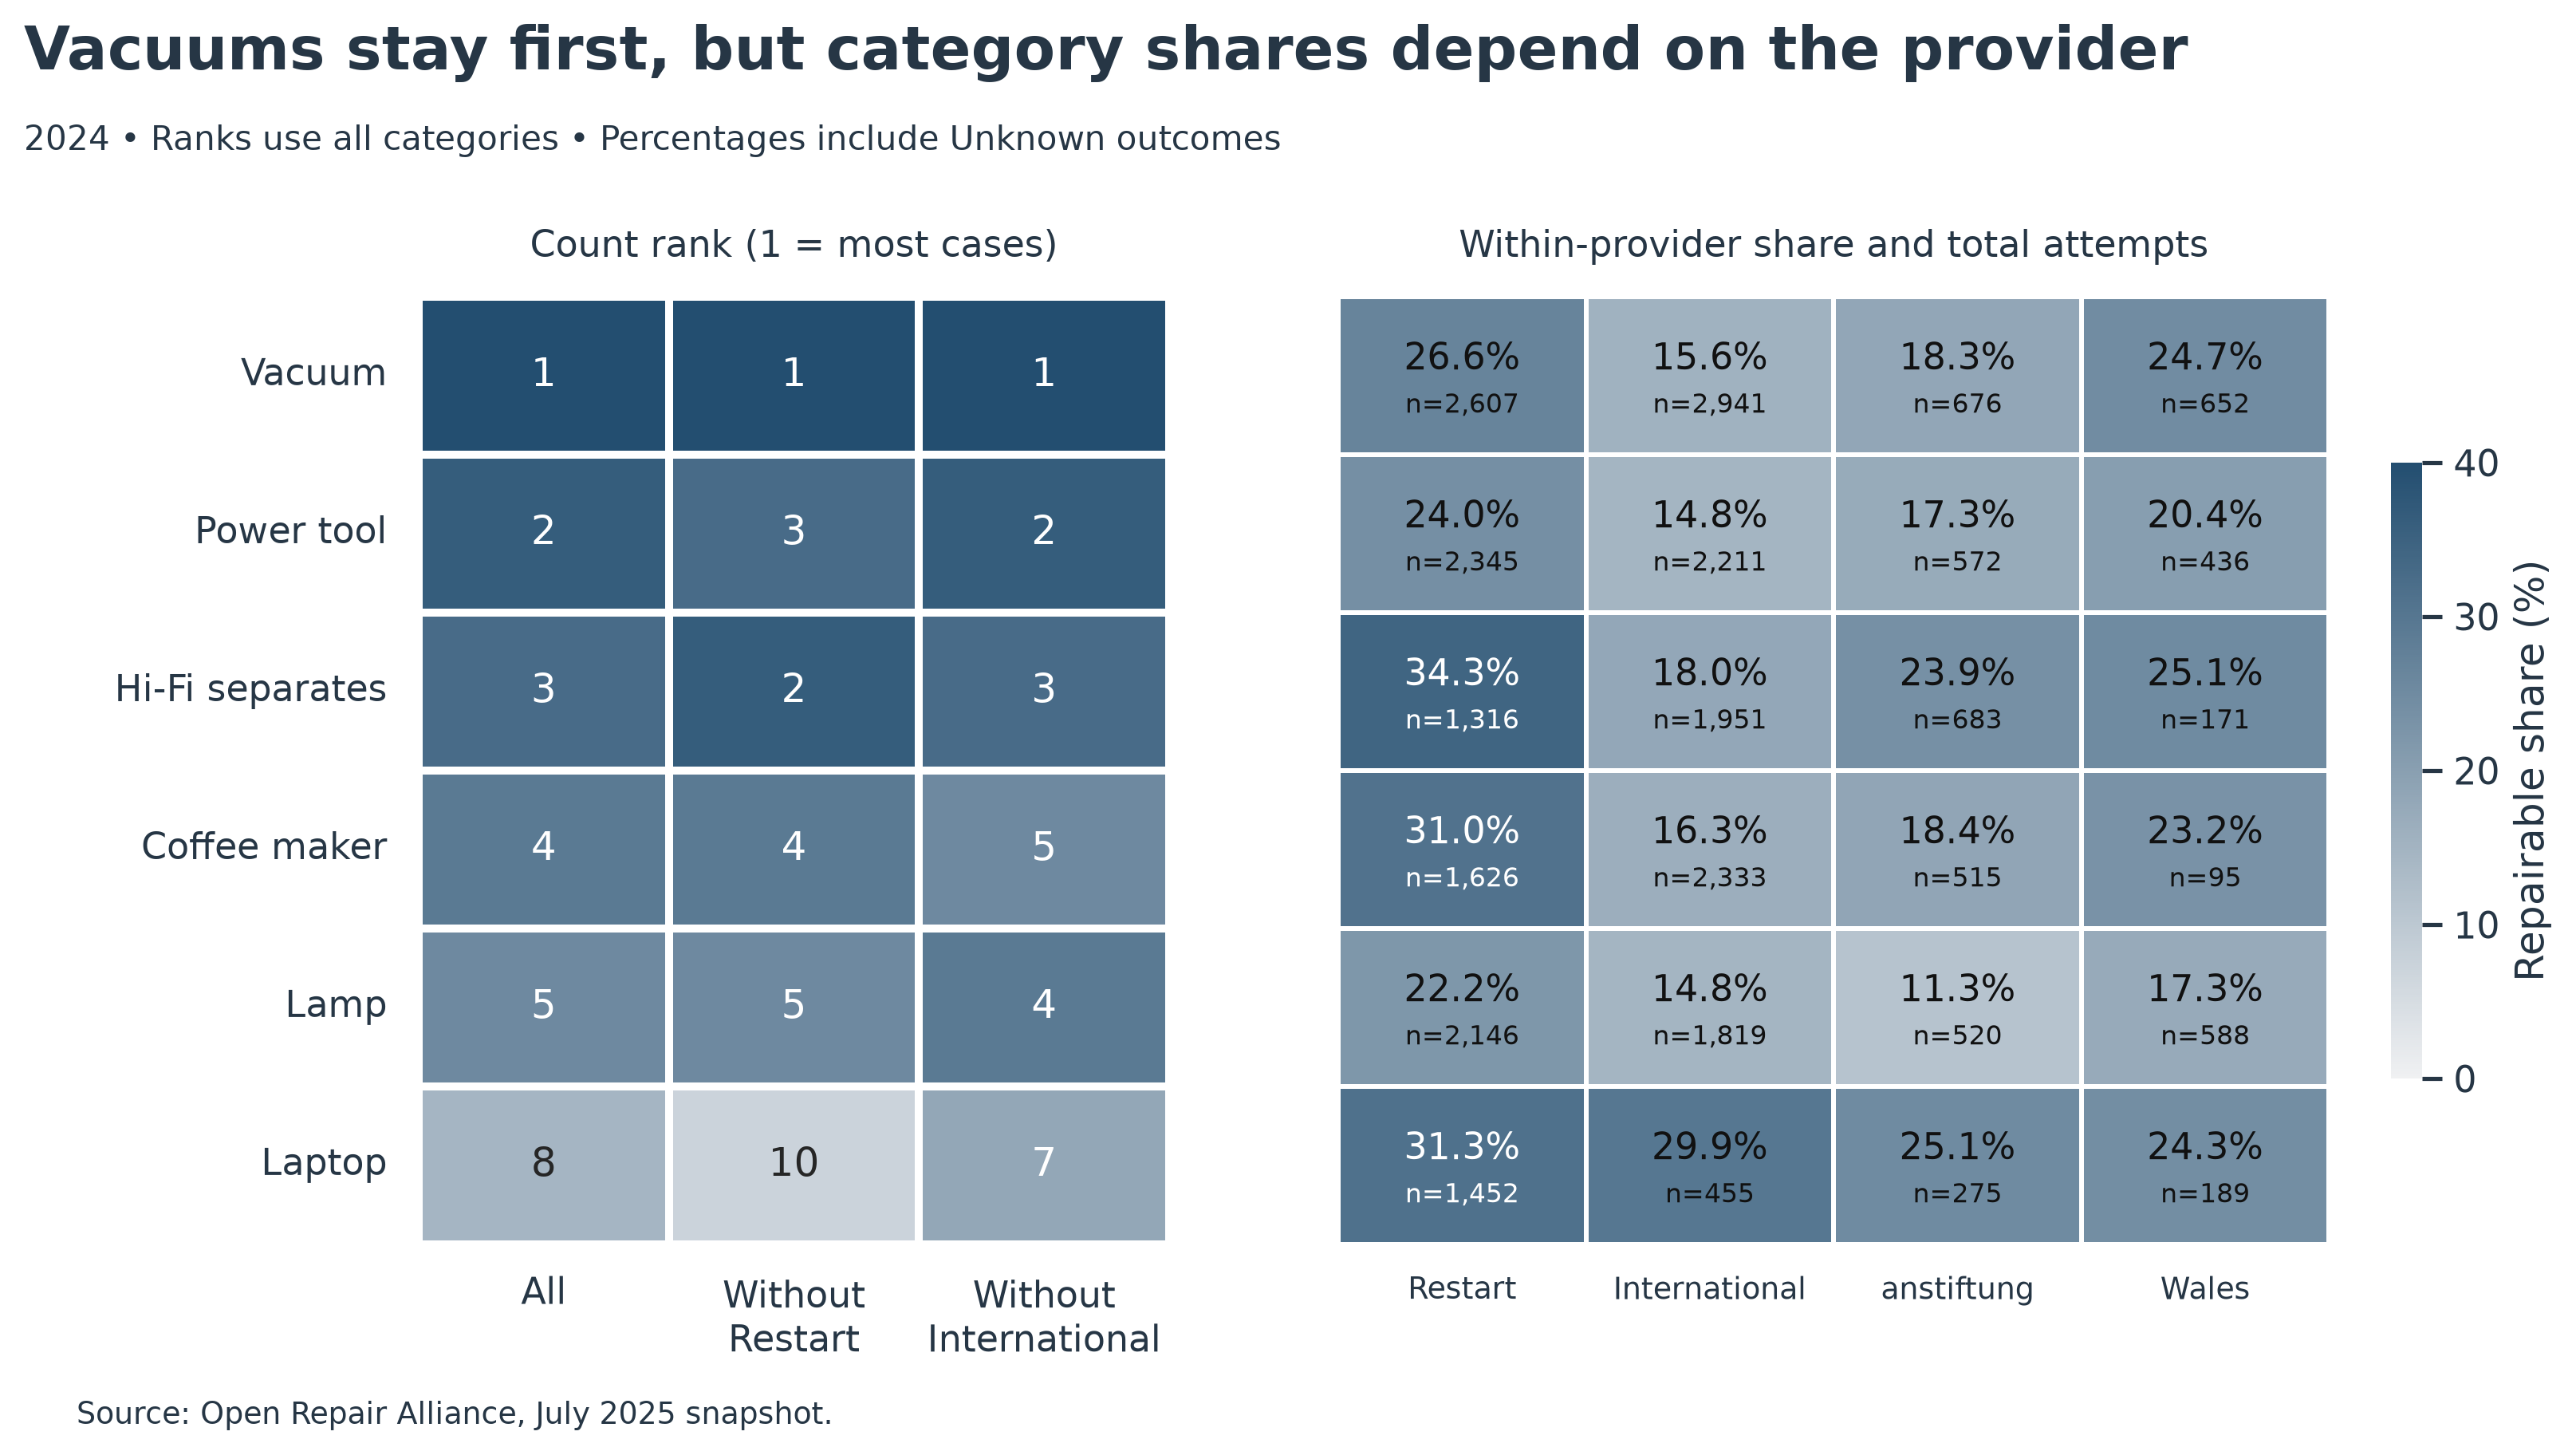

In [8]:
provider_names = ['The Restart Project', 'Repair Café International', 'anstiftung', 'Repair Cafe Wales']
samples = {'All': year, 'Without\nRestart': year[year.data_provider.ne(provider_names[0])],
           'Without\nInternational': year[year.data_provider.ne(provider_names[1])]}
ranks = pd.DataFrame({name: frame.groupby('product_category')['is_repairable'].sum()
                     .rank(ascending=False, method='min') for name, frame in samples.items()}).loc[categories]
profile = year.groupby(['product_category', 'data_provider'])['is_repairable'].agg(['sum', 'size'])
rates = (100 * profile['sum'] / profile['size']).unstack().loc[categories, provider_names]
base = profile['size'].unstack().loc[categories, provider_names]
fig, axes = plt.subplots(1, 2, figsize=(11, 6), gridspec_kw={'width_ratios': [1, 1.65]})
sns.heatmap(ranks, annot=True, fmt='.0f', cmap=sns.light_palette(NAVY, reverse=True, as_cmap=True), vmin=1, vmax=12,
            cbar=False, ax=axes[0], linewidths=2, linecolor='white')
sns.heatmap(rates, cmap=sns.light_palette(NAVY, as_cmap=True), vmin=0, vmax=40,
            cbar_kws={'label': 'Repairable share (%)', 'shrink': .65, 'ticks': [0, 10, 20, 30, 40]},
            ax=axes[1], linewidths=1, linecolor='white')
for (i, j), value in np.ndenumerate(rates.to_numpy()):
    colour = 'white' if value >= 30 else '#111111'
    axes[1].text(j+.5, i+.40, f'{value:.1f}%', ha='center', va='center', color=colour, fontsize=11)
    axes[1].text(j+.5, i+.69, f'n={base.iloc[i, j]:,.0f}', ha='center', va='center', color=colour, fontsize=8)
axes[0].set_title('Count rank (1 = most cases)', fontsize=11, pad=12)
axes[1].set_title('Within-provider share and total attempts', fontsize=11, pad=12)
axes[1].set_yticklabels([])
axes[1].set_xticklabels(['Restart', 'International', 'anstiftung', 'Wales'], rotation=0, fontsize=9)
for ax in axes:
    ax.set(xlabel='', ylabel='')
    ax.tick_params(axis='y', rotation=0)
heading(fig, 'Vacuums stay first, but category shares depend on the provider',
        '2024 • Ranks use all categories • Percentages include Unknown outcomes')
fig.subplots_adjust(left=.16, right=.98, top=.80, bottom=.14, wspace=.17)
plt.show()

Vacuum stays at rank 1 regardless of provider exclusion. The rest changes, though second and third places as well as fourth and fifth places just swap inside their group of two. This makes vacuums a consistent starting point and ranks two to five good next options, while small rank differences should carry less weight than local expertise and available support.\
The right panel shows a Repairable share is 34.3% at Restart compared with 18.0% at International for Hi-Fi separates. This shows that the combined percentage can hide substantial differences between providers.

This sensitivity check does not prove the ranking holds everywhere, as just two providers were excluded. Also the provider case mix and recording differences affect percentages.

## 4. Repairable cases recur throughout the year

For better planning the coordinator should know if cases are consistent during the year or concentrated in a short period. This figure groups the four categories with the highes volume by month and shows their Repairable counts and share of all attempts over the course of the year (2024).

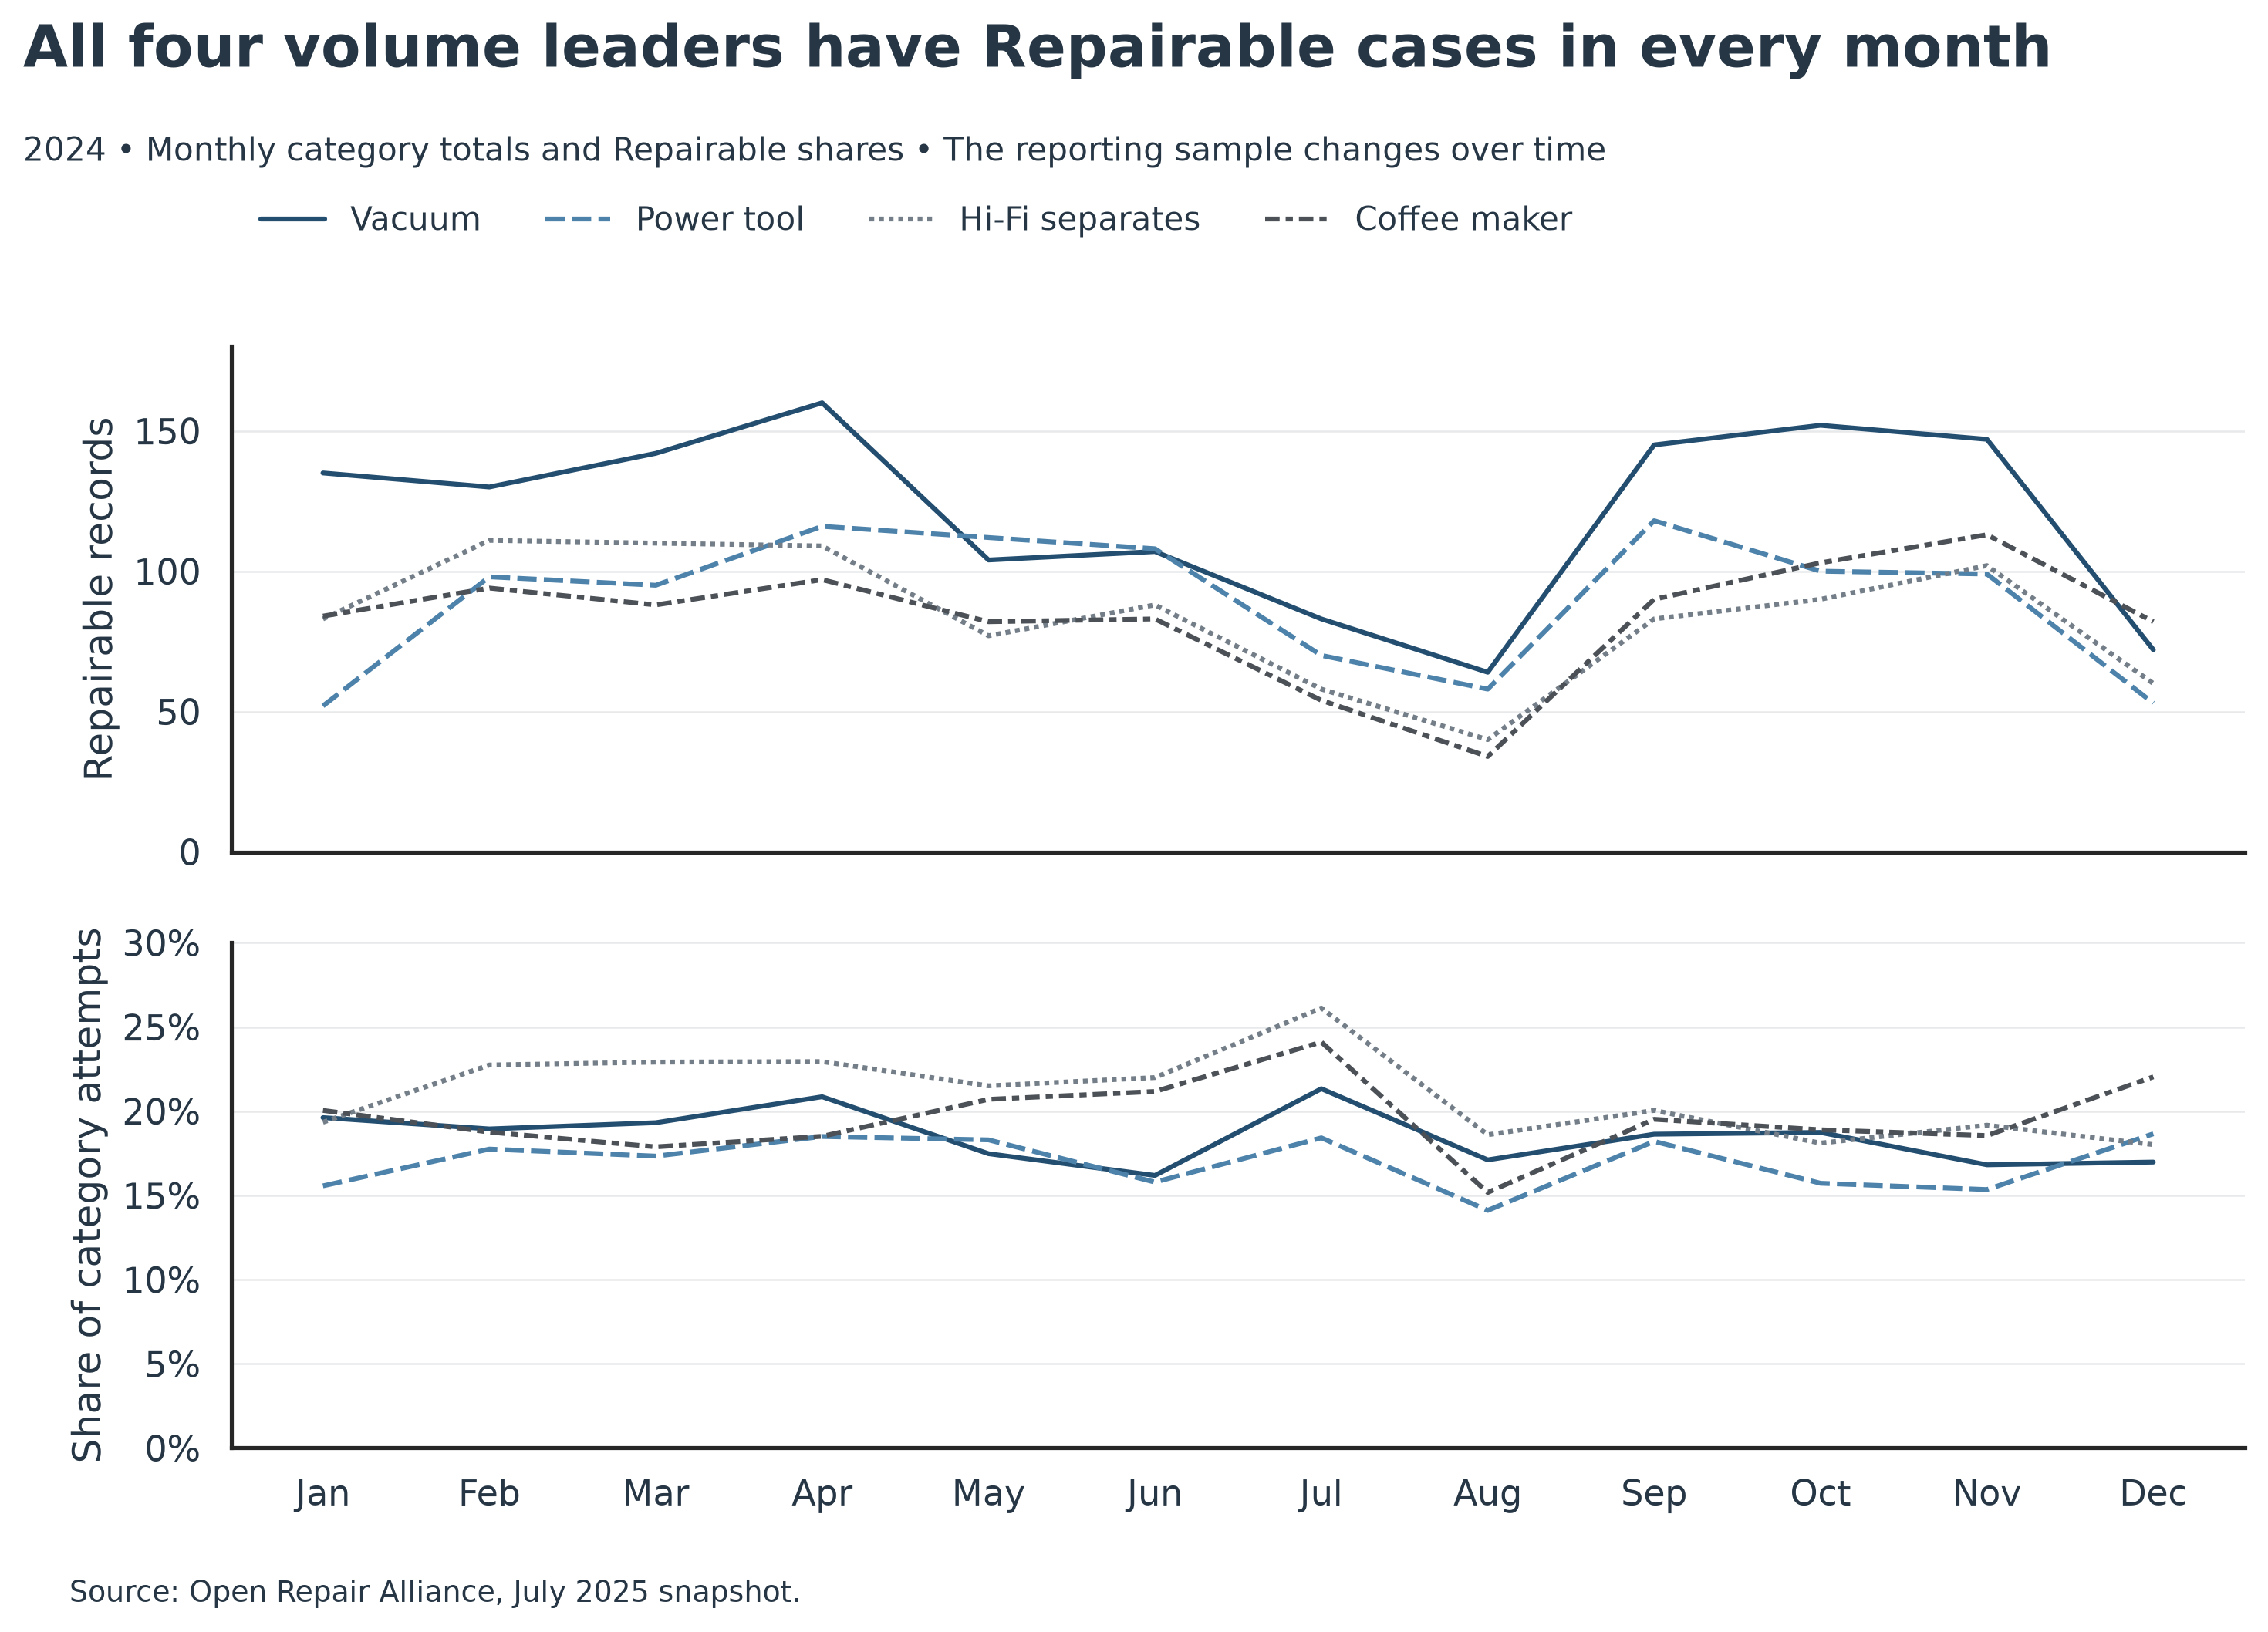

In [9]:
leaders = categories[:4]
monthly = year[year.product_category.isin(leaders)].groupby(
    ['month', 'product_category'])['is_repairable'].agg(['sum', 'size']).reset_index()
monthly['share'] = 100 * monthly['sum'] / monthly['size']
palette = dict(zip(leaders, [NAVY, BLUE, '#737E88', '#4B5157']))
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, measure, label, limit in zip(axes, ['sum', 'share'],
        ['Repairable records', 'Share of category attempts'], [(0, 180), (0, 30)]):
    sns.lineplot(data=monthly, x='month', y=measure, hue='product_category',
                 style='product_category', hue_order=leaders, style_order=leaders,
                 palette=palette, dashes=True, ax=ax, legend=False)
    ax.set(ylabel=label, ylim=limit, xlabel='')
    ax.grid(axis='y', color='#E7E9EB', lw=.6)
axes[1].yaxis.set_major_formatter(PercentFormatter(decimals=0))
axes[1].set_xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
fig.legend(axes[0].lines[:4], leaders, loc='upper left', bbox_to_anchor=(.10, .895),
           ncol=4, frameon=False, fontsize=10)
heading(fig, 'All four volume leaders have Repairable cases in every month',
        '2024 • Monthly category totals and Repairable shares • The reporting sample changes over time')
fig.subplots_adjust(left=.10, right=.97, top=.79, bottom=.11, hspace=.18)
plt.show()

All leading categories have Repairable cases each month of 2024, with a dip in the summer month and in December (which could be due to fewer people working at the repair shops during summer and Christmas holidays). The share of Repairable outcomes stays relatively consistent with slightly higher shares in July.\
This supports regular follow-up arrangements rather than responding to peaks.

## 5. Large network totals are spread across many groups

For local service planning network totals can be misleading, since they are spread out over many groups (groups are individual repair groups within each provider’s network, identified by the combination of data_provider and group_identifier).\
The following figure show cumulative curves with different denominators using Laptops and Vacuums as an example. The left panel shows the cumulative distribution of reported cases per group with the curve providing the percentage of groups at or below a case count. The right panel orders groups from busiest to least busy, then their shares of groups and cases are accumulated. Each category includes all groups that reported at least one repair attempt for that product type, even if none of those attempts were classified as Repairable.

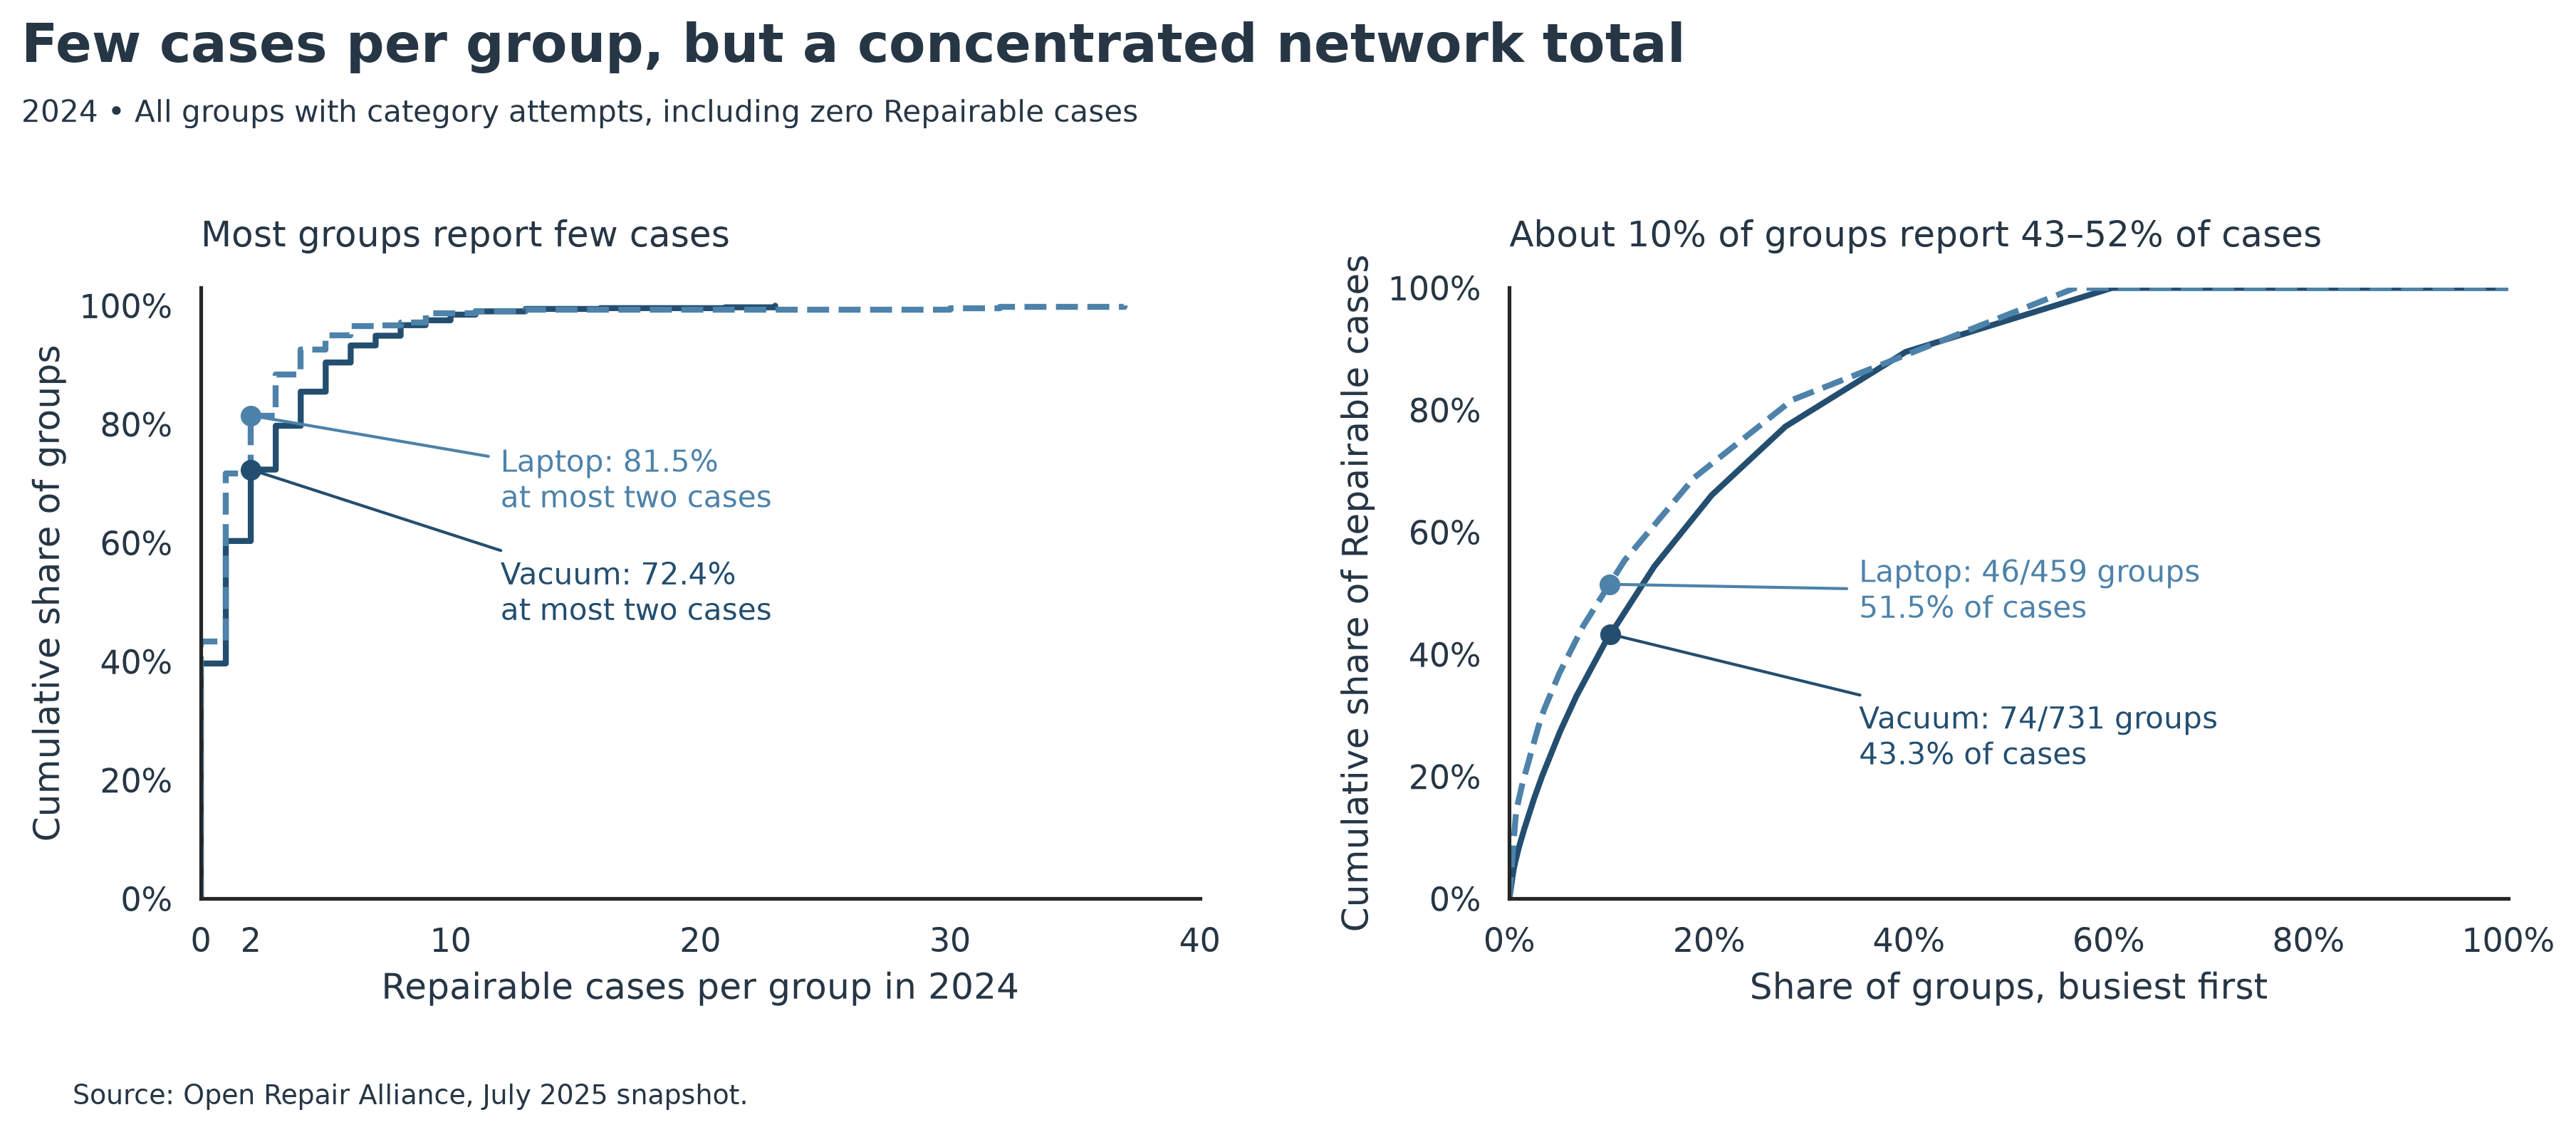

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for category, color, style in zip(['Vacuum', 'Laptop'], [NAVY, BLUE], ['-', '--']):
    groups = year[year['product_category'].eq(category)].groupby(
        ['data_provider', 'group_identifier'])['is_repairable'].sum()
    sns.ecdfplot(x=groups, stat='percent', ax=axes[0], color=color,
                 linestyle=style, linewidth=2, label=category)
    below_two = 100 * groups.le(2).mean()
    axes[0].scatter(2, below_two, color=color, zorder=3)
    label_y = 47 if category == 'Vacuum' else 66
    axes[0].annotate(f'{category}: {below_two:.1f}%\nat most two cases',
                     (2, below_two), (12, label_y), fontsize=10, color=color,
                     arrowprops={'arrowstyle': '-', 'color': color})
    ranked = groups.sort_values(ascending=False)
    group_share = np.r_[0, np.arange(1, len(ranked) + 1) / len(ranked) * 100]
    case_share = np.r_[0, ranked.cumsum() / ranked.sum() * 100]
    axes[1].plot(group_share, case_share, color=color, linestyle=style, linewidth=2)
    top_n = int(np.ceil(.10 * len(ranked)))
    axes[1].scatter(group_share[top_n], case_share[top_n], color=color, zorder=3)
    label_y = 22 if category == 'Vacuum' else 46
    axes[1].annotate(f'{category}: {top_n}/{len(ranked)} groups\n'
                     f'{case_share[top_n]:.1f}% of cases',
                     (group_share[top_n], case_share[top_n]), (35, label_y),
                     fontsize=10, color=color,
                     arrowprops={'arrowstyle': '-', 'color': color})
axes[0].set(xlim=(0, 40), ylim=(0, 103),
            xlabel='Repairable cases per group in 2024',
            ylabel='Cumulative share of groups')
axes[0].set_xticks([0, 2, 10, 20, 30, 40])
axes[0].set_title('Most groups report few cases', loc='left', fontsize=12, pad=14)
axes[1].set(xlim=(0, 100), ylim=(0, 100),
            xlabel='Share of groups, busiest first',
            ylabel='Cumulative share of Repairable cases')
axes[1].set_title('About 10% of groups report 43–52% of cases', loc='left', fontsize=12, pad=14)
axes[1].xaxis.set_major_formatter(PercentFormatter())
for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter())
heading(fig, 'Few cases per group, but a concentrated network total',
        '2024 • All groups with category attempts, including zero Repairable cases')
fig.subplots_adjust(left=.08, right=.98, top=.75, bottom=.20, wspace=.31)
plt.show()

The main evidence here is that 72.4% of vacuum-reporting groups only recorded at most two Repairable cases, while the busiest 10% of groups accounted for 43.3% of vacuum cases. This explains how small local counts coexist with large network totals, though one limiting factor is that Denmark has zero reported Repairable outcomes, which contributes to the many low-count groups.

For the coordinator this could mean pooled specialists, shared resources or referrals should be explored before assuming each group needs a dedicated category service. The concentration curve also suggests investigating groups with high case-counts for the pilot.

## 6. Repeated brands give support a starting point

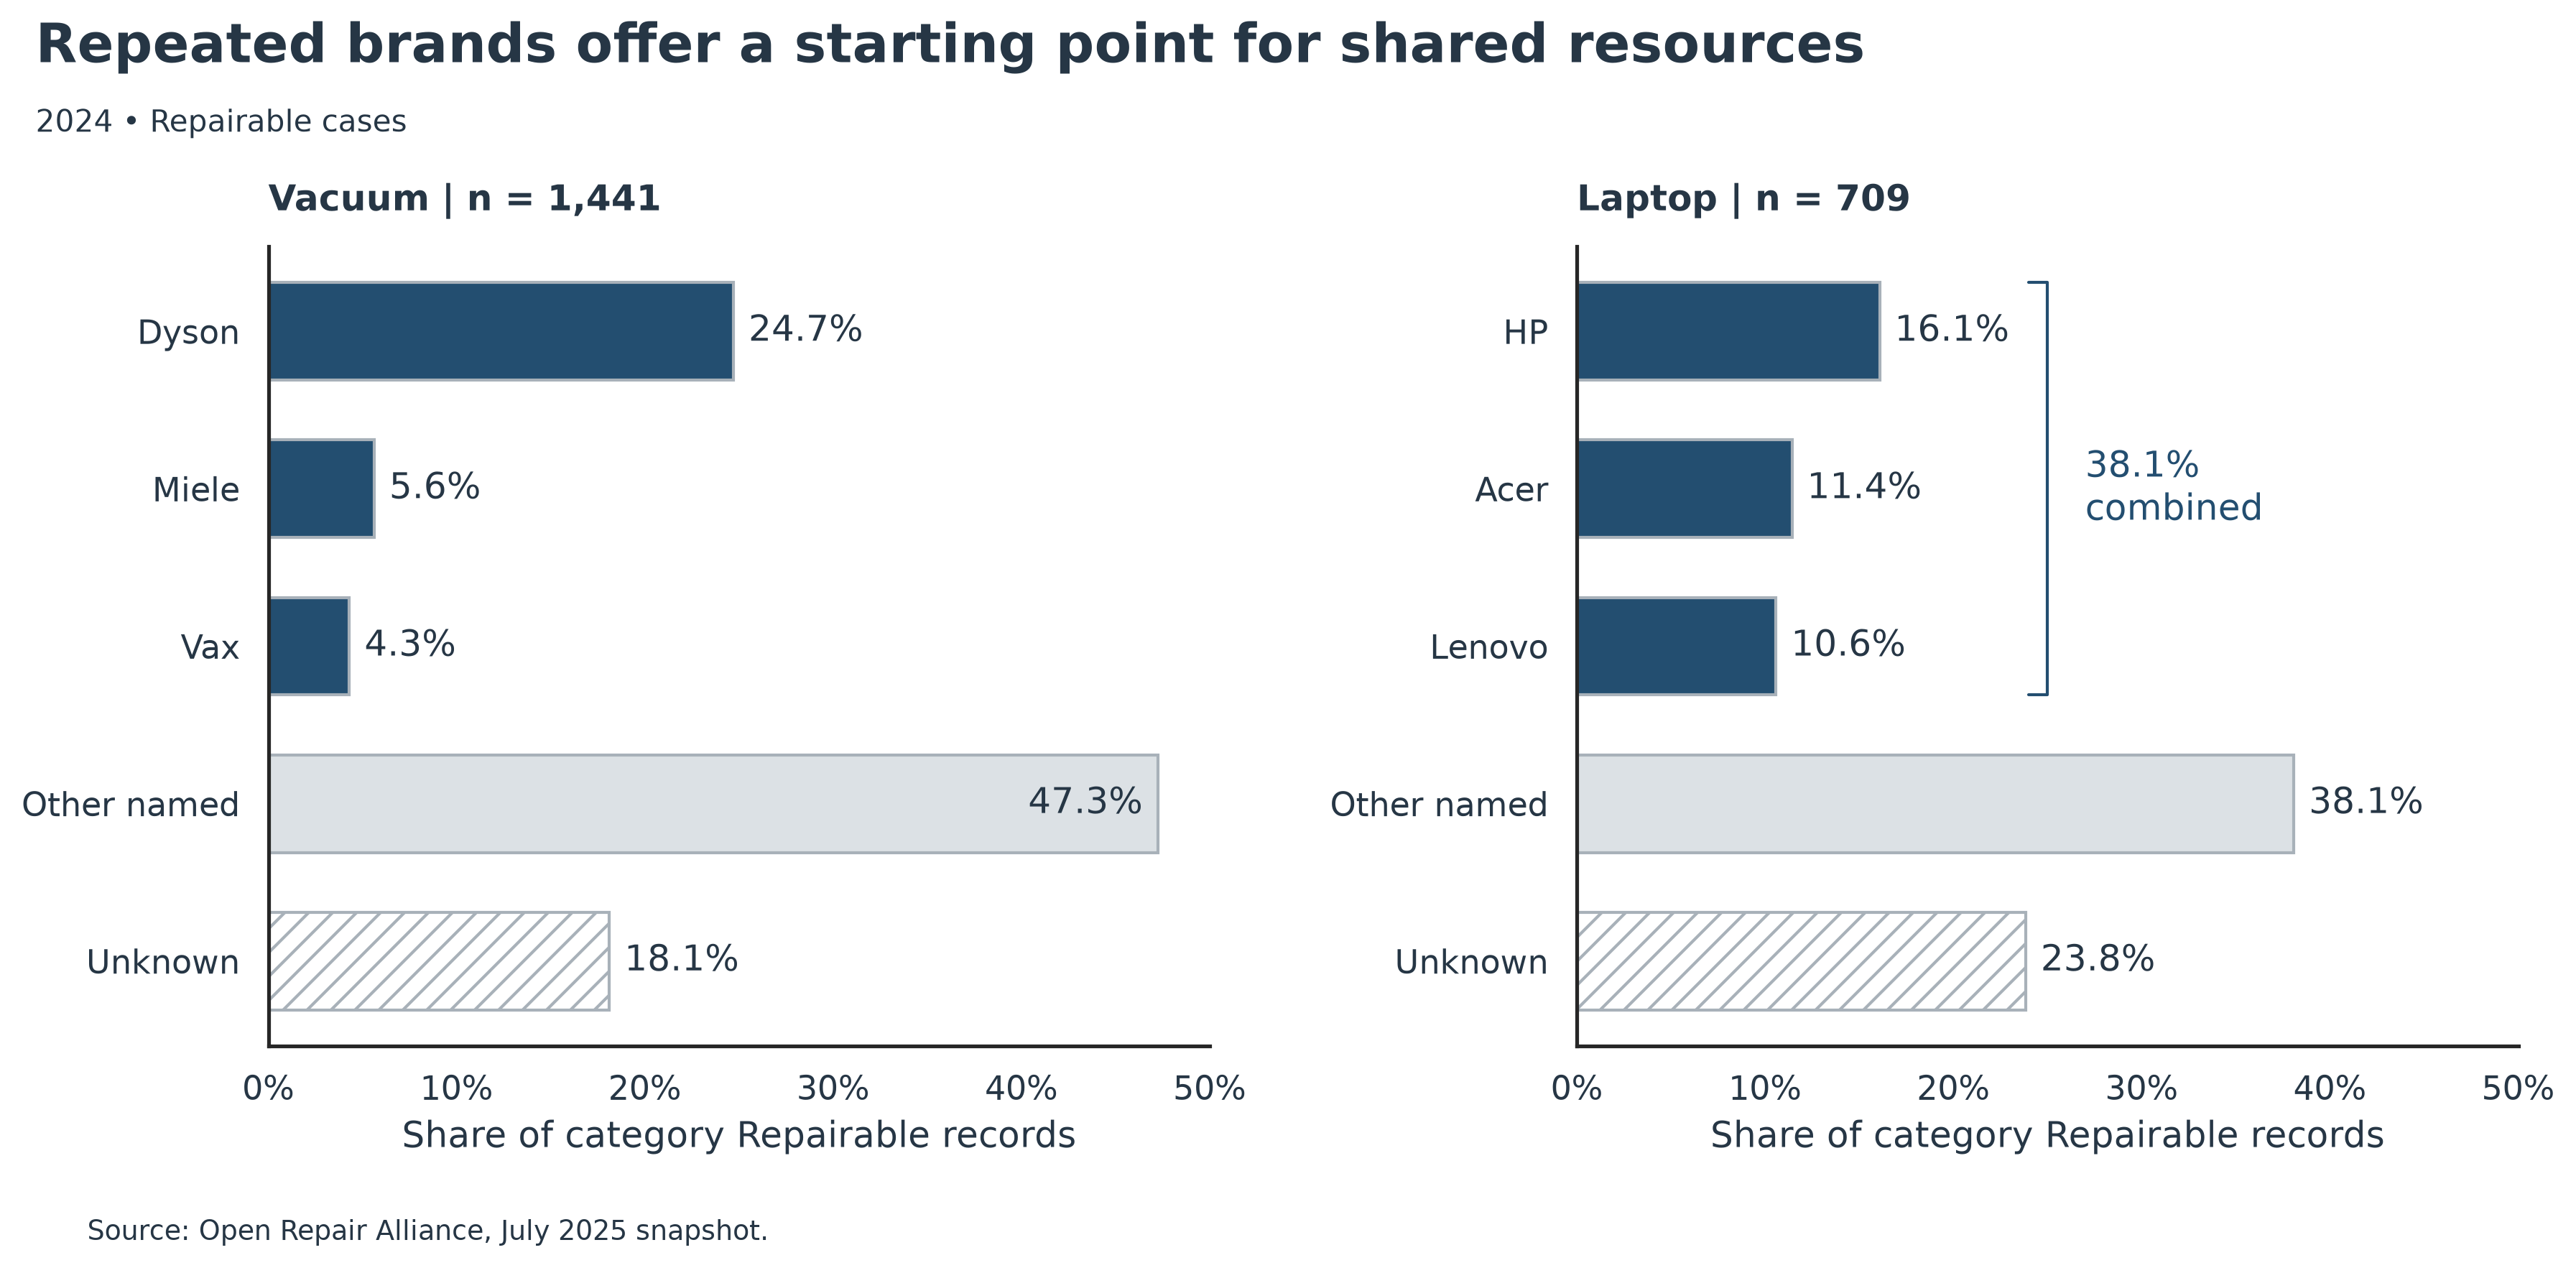

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), sharex=True)
for ax, category in zip(axes, ['Vacuum', 'Laptop']):
    brands = repairable.loc[repairable['product_category'].eq(category), 'brand_clean']
    counts = brands.value_counts()
    named = counts.drop('Unknown', errors='ignore')
    top = named.nlargest(3)
    labels = [('HP' if b == 'hp' else b.title()) for b in top.index] + ['Other named', 'Unknown']
    shares = np.r_[top.values, named.sum()-top.sum(), counts.get('Unknown', 0)]/len(brands)*100
    bars = ax.barh(labels, shares, color=[NAVY]*3+['#DCE1E5', 'white'], edgecolor=GREY, height=.62)
    bars[-1].set_hatch('///')
    for bar, share in zip(bars, shares):
        ax.text(share-.8 if share>43 else share+.8, bar.get_y()+.31, f'{share:.1f}%',
                va='center', ha='right' if share>43 else 'left')
    ax.invert_yaxis()
    ax.set_title(f'{category} | n = {len(brands):,}', loc='left', pad=12, fontweight='bold')
    if category == 'Laptop':
        ax.plot([24, 25, 25, 24], [-.31, -.31, 2.31, 2.31], color=NAVY, lw=1)
        ax.text(27, 1, f'{top.sum()/len(brands):.1%}\ncombined', va='center', color=NAVY)
    ax.set(xlim=(0, 50), xlabel='Share of category Repairable records')
    ax.xaxis.set_major_formatter(PercentFormatter(100))
heading(fig, 'Repeated brands offer a starting point for shared resources',
        '2024 • Repairable cases')
fig.subplots_adjust(left=.10, right=.97, bottom=.17, top=.81, wspace=.39)
plt.show()

After choosing categories and considering shared support, the coordinator needs a starting point for preparing supporting materials like manuals, model information and volunteer expertise. 

The top three (cleaned) brand names are shown separately, highlighting Dyson as the most frequently recorded brand of vacuums with a 24.7% share and HP, Acer and Lenovo as the most frequently recorded Laptop brands having a combined share of 38.1%, equal to all other named brands combined. 

The coordinator should therefore focus the resources, as well as the volunteer experience on these brands as a starting point for shared preparation. Still other things like brand reliability, parts compatibility, repair cost or whether a single resource works across models should be considered before a final decision.

## 7. Similar volumes hide very different product ages

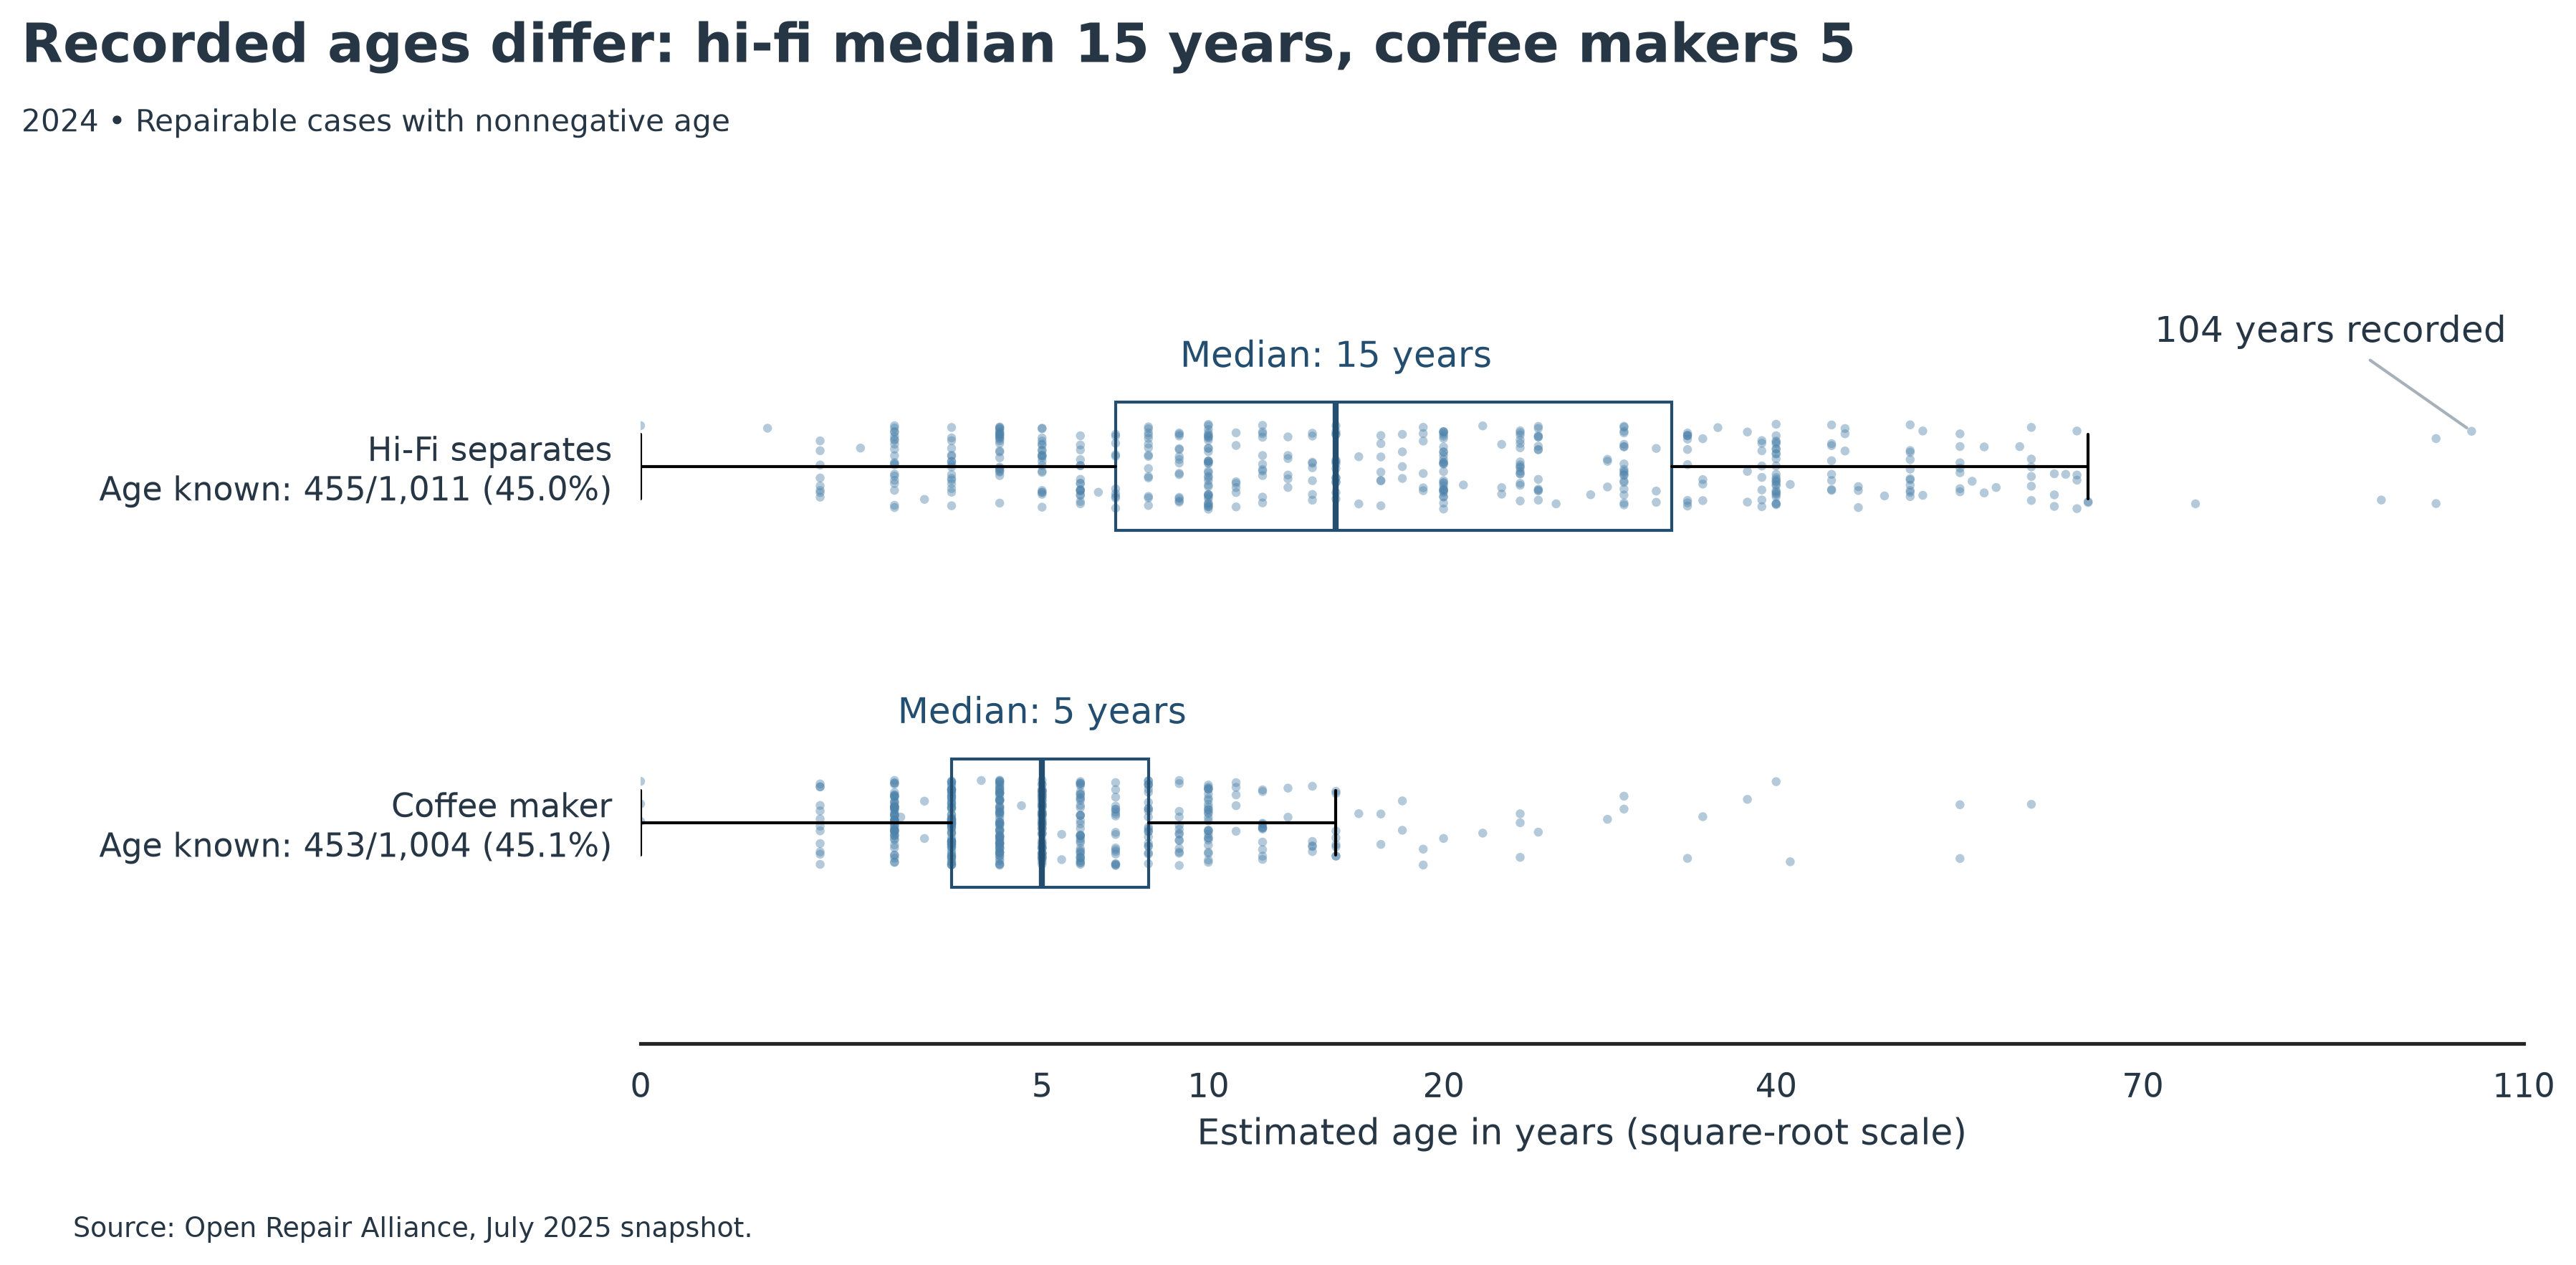

In [12]:
fig, ax = plt.subplots(figsize=(12, 5.8))
rng = np.random.default_rng(42)
labels = []
for i, category in enumerate(['Hi-Fi separates', 'Coffee maker']):
    subset = repairable[repairable['product_category'].eq(category)]
    ages = pd.to_numeric(subset['product_age'], errors='coerce')
    ages = ages[ages.ge(0)]
    jitter = rng.uniform(-.12, .12, len(ages))+i
    ax.scatter(ages, jitter, s=9, alpha=.42, color=BLUE, edgecolors='none')
    ax.boxplot(ages, positions=[i], orientation='horizontal', widths=.36,
               showfliers=False, manage_ticks=False, patch_artist=True,
               boxprops={'facecolor': 'none', 'edgecolor': NAVY},
               medianprops={'color': NAVY, 'linewidth': 2})
    median = ages.median()
    ax.text(median, i-.28, f'Median: {median:g} years', ha='center', color=NAVY)
    labels.append(f'{category}\nAge known: {len(ages)}/{len(subset):,} ({len(ages)/len(subset):.1%})')
    if category == 'Hi-Fi separates':
        ax.annotate(f'{ages.max():g} years recorded',
                    (ages.max(), jitter[ages.argmax()]), (108, -.35), ha='right',
                    arrowprops={'arrowstyle': '-', 'color': GREY})
ax.set(yticks=[0, 1], yticklabels=labels, xlim=(0, 110), ylim=(1.62, -.62),
       xlabel='Estimated age in years (square-root scale)')
ax.set_xscale('function', functions=(np.sqrt, np.square))
ax.set_xticks([0, 5, 10, 20, 40, 70, 110])
sns.despine(ax=ax, left=True)
heading(fig, 'Recorded ages differ: hi-fi median 15 years, coffee makers 5',
        '2024 • Repairable cases with nonnegative age')
fig.subplots_adjust(left=.25, right=.98, bottom=.17, top=.81)
plt.show()

The last insight shows why two categories with almost equal Repairable volume may need different preparation and how product age helps investigate that difference. 

Hi-Fi separates and Coffee makers were chosen as interestig examples using all usable nonnegative ages. The box plots help identify the median age (15 years for Hi-Fi and 5 years for coffee makers) and middle half, while the overlaid points reveal the spread beyond those summaries (vertical offset only separates overlapping points). I compressed the scale to reduce the effects of a few very old products (including a gramophone, record players and radios) so equal distance does not mean equal age difference.

The business implication here is to try to match volunteer experience/expertise with the most common ages/generations of products in each category. But the significance is limited because only around 45% of products in those two categories included usable ages, so missingness may bias the comparison.

## Recommendation and limitations

My recommendation is to start the pilot with vacuums. They have the largest Repairable count and remain first in both provider-exclusion checks. Additionally the coordinator should consider shared support rather than assuming a separate service at every reporting group, since total cases per group were quite small for most groups.\
Power tools could be added next as they add substantial recorded volume. And the coordinator could choose among hi-fi, coffee makers and laptops according to local expertise, available resources and the type of follow-up that can actually be offered.

I chose three scenarios to compare historical coverage of three-category portfolios:

| Three-category scenario | Repairable records | Share of all 2024 Repairable records |
|---|---:|---:|
| Vacuum, power tool, hi-fi | 3,531 | 24.0% |
| Vacuum, power tool, coffee maker | 3,524 | 24.0% |
| Vacuum, laptop, coffee maker | 3,154 | 21.5% |

The first two scenarios appear most practical and since they differ by only seven historical cases local expertise can reasonably matter more than that count gap. The laptop-containing scenario covers fewer historical records but may suit a different support capability better.

While the analysis combines counts, shares and provider checks rather than relying on one ranking, the findings are still limited by different factors: the reporting is voluntary, the definitions may differ by provider and combined with the different outcome profiles and missing ages it constrains transferability, the records are attempts rather than linked product histories. Additionally willingness to accept follow-up, effort, cost, local capacity and compatibility of parts or models are all unknown, so the findings only justify testing a pilot, but actual effectiveness is not proven.

The next step would be to test follow-up support for vacuums in a small pilot. The network should record what support was offered, whether owners accepted it, whether the repair was completed and how much time and money it required. Outcomes should be checked after a defined follow-up period. This would help the coordinator decide whether to expand the service or adjust it.

## References

Open Repair Alliance (2025) *Open Repair Data: July 2025 snapshot*. Available at: https://github.com/openrepair/data (Accessed: 14 September 2026). CC BY-SA 4.0.

Open Repair Alliance (n.d.) *Open Repair Data Standard, version 0.3*. Available at: https://github.com/openrepair/datastandard (Accessed: 14 September 2026).

The Restart Project (n.d.) *What does “repairable” mean?* Available at: https://therestartproject.org/hrf_faq/what-does-repairable-mean/ (Accessed: 14 September 2026).

Project source: [GitHub repository](https://github.com/komaboe/beyond-the-repair-event).